## 1.2 Cleaning and converting the articles

In notebook 1.1 we worked out how to recover the three things we need from each article: the real source, the real publish time, and the clean body text. This notebook puts those methods together into one pipeline and runs it over the open corpus to build the processed dataset. The detailed testing for each step is in 1.1. Here we keep only the final code and a short note on what each step does.

### 1. Overview and setup

The pipeline fetches each article once and parses it once, reading the source, time, and body from the same page. It only fetches a second time if it has to follow a canonical link. This setup cell loads the corpus, sets the list of readable sources from 1.1, and defines the shared parts every step uses: a session that pools connections and retries, and a helper that reads the JSON-LD data from a page.

In [ ]:
import json
import re
import time
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import timezone
from urllib.parse import urlparse

import pandas as pd
import requests
from bs4 import BeautifulSoup
from dateutil import parser as date_parser
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from stock_predictor.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, REPORTS_DIR, FIGURES_DIR

articles = pd.read_parquet(RAW_DATA_DIR / "raw_articles.parquet")
open_sources = ["Yahoo", "Benzinga", "DowJones"]  # readable sources from the probe (1.1)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
    )
}
MAX_WORKERS = 8
TIMEOUT = 12
MIN_BODY_CHARS = 500
MAX_SHIFT_HOURS = 6  # a scraped time this far from the API time is treated as a repost
REQ_PER_SEC = 3.5   # global fetch rate, held under Yahoo's 429 limit


def make_session():
    """A pooled, retrying session shared across the worker threads."""
    s = requests.Session()
    s.headers.update(HEADERS)
    # Bounded backoff, ignore Retry-After (Yahoo's is long enough to stall a worker),
    # and return the final response instead of raising, so a throttle shows as 429.
    retry = Retry(total=2, backoff_factor=0.5, backoff_max=8,
                  status_forcelist=[429, 500, 502, 503, 504],
                  respect_retry_after_header=False, raise_on_status=False)
    adapter = HTTPAdapter(max_retries=retry, pool_connections=MAX_WORKERS,
                          pool_maxsize=MAX_WORKERS * 2)
    s.mount("https://", adapter)
    s.mount("http://", adapter)
    return s


class Pacer:
    """Cap the request rate across all worker threads to REQ_PER_SEC, so the pool
    does not burst and trip Yahoo's 429 limit."""
    def __init__(self, per_second):
        self._interval = 1.0 / per_second
        self._lock = threading.Lock()
        self._next = 0.0

    def wait(self):
        with self._lock:
            now = time.monotonic()
            start = max(now, self._next)
            self._next = start + self._interval
        time.sleep(start - now)


pacer = Pacer(REQ_PER_SEC)


def _ld_objects(soup):
    """Yield each JSON-LD object on the page, flattening list payloads."""
    for tag in soup.find_all("script", type="application/ld+json"):
        try:
            data = json.loads(tag.string or "")
        except (json.JSONDecodeError, TypeError):
            continue
        for obj in (data if isinstance(data, list) else [data]):
            if isinstance(obj, dict):
                yield obj


print(f"Loaded {len(articles)} articles")

## Building the pipeline by stage

Each step is a small function that reads from the parsed page. Further on we combine them into one pass per article.

### 2. Stage 1: the source

When Yahoo republishes another outlet's article, the page's structured data names the original outlet in a `provider` field. We use that first, then the `publisher` field, and if neither is there we fall back to the final host. The `provider` field is what tells us the real outlet behind a Yahoo repost. Full analysis in 1.1, section 3.2.

In [11]:
def _true_source(soup, host):
    """Prefer the original outlet in the provider field, then the publisher, then the host."""
    provider = publisher = None
    for obj in _ld_objects(soup):
        prov = obj.get("provider")
        if provider is None and prov:
            provider = prov.get("name") if isinstance(prov, dict) else (prov if isinstance(prov, str) else None)
        pub = obj.get("publisher")
        if publisher is None and isinstance(pub, dict) and pub.get("name"):
            publisher = pub["name"]
    return provider or publisher or host

### 3. Stage 2: the time

We read `datePublished` from the structured data and parse it to UTC. A time with no timezone is not trusted. On a repost the page's time can be the repost or refresh time instead of the original, so we follow the canonical link to the original publisher to get the real first publish time. This is the only place a second fetch happens.

We then treat the recovered time as a candidate against the Finnhub API time, not as an automatic replacement. If the original comes from a different host it is the outlet's own page, so we trust it. If it comes from the same host we trust it only when it is within `MAX_SHIFT_HOURS` of the API time. Otherwise we keep the API time. This keeps the real fixes, the Eastern timezone shift and the cross-host wins, and drops the wrong repost times. It also means the API time is a floor, so no article loses its time. Full analysis in 1.1, sections 3.4 and 3.6.

In [12]:
def _published(soup):
    """Read the published time from JSON-LD, or fall back to a meta tag."""
    for obj in _ld_objects(soup):
        if obj.get("datePublished"):
            return obj["datePublished"]
    m = soup.find("meta", attrs={"property": "article:published_time"})
    return m["content"] if m and m.get("content") else None


def _to_utc(value):
    """Parse an ISO time to UTC. Naive (zoneless) times are not trusted."""
    if not value:
        return None
    try:
        dt = date_parser.parse(value)
    except (ValueError, TypeError, OverflowError):
        return None
    if dt.tzinfo is None:
        return None
    return dt.astimezone(timezone.utc)


def _resolve_time(candidate, api_utc, cross_host):
    """Pick the trustworthy time, with the API time as the floor: trust a
    cross-host original outright, a same-host time only within MAX_SHIFT_HOURS,
    else keep the API time so no article is dropped for want of a page time."""
    if candidate is None:
        return api_utc, "api"
    if cross_host:
        return candidate, "corrected"
    if abs((candidate - api_utc).total_seconds()) <= MAX_SHIFT_HOURS * 3600:
        return candidate, "corrected"
    return api_utc, "api"

### 4. Stage 3: the body

We remove the script, style, and layout tags, join the paragraph text, and collapse the whitespace. We keep an article only when its cleaned body is at least `MIN_BODY_CHARS`. Short stubs and cookie-consent pages get dropped here.

In [13]:
def _clean_body(soup):
    """Drop chrome tags, join the paragraph text, collapse whitespace."""
    for tag in soup(["script", "style", "nav", "aside", "footer", "header", "form", "figure"]):
        tag.decompose()
    text = " ".join(p.get_text(" ", strip=True) for p in soup.find_all("p"))
    return re.sub(r"\s+", " ", text).strip()

### 5. Composing the stages

`process_article` runs the three steps on one page and records whether each one passed. The time is always resolved against the Finnhub API time (`_resolve_time`), so every article we reach ends up with a usable time, which leaves the body as the only thing that can fail. `run_pipeline` runs this over the whole corpus using a shared session and 8 worker threads. We accept an article when its body is long enough. A missing source is fine, because it falls back to the host.

In [14]:
def process_article(row, session):
    """Fetch one article once and derive source, UTC time, and body. A second
    fetch fires only to follow a cross-host canonical link for the true time."""
    out = {"article_id": row["article_id"], "true_source": None, "utc": None,
           "time_source": None, "raw_body": None, "processed_body": None,
           "status": None, "source_ok": False, "corrected": False,
           "text_ok": False, "n_fetch": 0}
    url = row["url"]
    try:
        pacer.wait()  # hold the global rate
        r = session.get(url, timeout=TIMEOUT)
        out["n_fetch"] = 1
        out["status"] = r.status_code
        if r.status_code != 200:
            return out
        host = urlparse(r.url).netloc
        soup = BeautifulSoup(r.text, "html.parser")

        out["true_source"] = _true_source(soup, host)
        out["source_ok"] = out["true_source"] is not None

        published = _published(soup)
        cross_host = False
        link = soup.find("link", rel="canonical")
        canonical = link["href"] if link and link.get("href") else None
        if canonical and urlparse(canonical).netloc not in ("", host):
            try:
                r2 = session.get(canonical, timeout=TIMEOUT)
                out["n_fetch"] = 2
                if r2.status_code == 200:
                    original = _published(BeautifulSoup(r2.text, "html.parser"))
                    if original:
                        published, cross_host = original, True
            except requests.RequestException:
                pass

        candidate = _to_utc(published)
        api_utc = row["timestamp_utc"].to_pydatetime()
        out["utc"], out["time_source"] = _resolve_time(candidate, api_utc, cross_host)
        out["corrected"] = out["time_source"] == "corrected"

        out["raw_body"] = r.text
        out["processed_body"] = _clean_body(soup)
        out["text_ok"] = len(out["processed_body"]) >= MIN_BODY_CHARS
    except requests.RequestException as e:
        out["status"] = type(e).__name__  # record the error kind (Timeout, ConnectionError)
    return out


def run_pipeline(articles, max_workers=MAX_WORKERS):
    """Run process_article over every row in parallel, preserving order."""
    rows = articles.to_dict("records")
    results = [None] * len(rows)
    with make_session() as session, ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(process_article, row, session): i for i, row in enumerate(rows)}
        for f in as_completed(futs):
            results[futs[f]] = f.result()
    return pd.DataFrame(results)

## Running the pipeline

Run the composed pipeline over the open corpus, count what survives, and save the result.

### 6. Running across the open corpus

Drop the blocked sources and run over the open ones, around 2.7k articles.

In [15]:
open_articles = articles[articles["source"].isin(open_sources)].copy()

results = run_pipeline(open_articles)

merged = open_articles.merge(
    results[["article_id", "true_source", "utc", "raw_body", "processed_body",
             "status", "source_ok", "corrected", "time_source", "text_ok", "n_fetch"]],
    on="article_id", how="left",
)
print(f"{len(merged)} articles, {int(results['n_fetch'].sum())} fetches")

2742 articles, 2983 fetches


### 7. Results and losses

In [16]:
n = len(merged)
accept = merged["text_ok"]   # time always resolves (API floor), so text is the gate

print(f"open corpus          : {n}")
print(f"page reached (200)   : {merged['status'].eq(200).sum()}")
print(f"source recovered     : {merged['source_ok'].sum()}")
print(f"ACCEPTED             : {accept.sum():>4} ({accept.mean():.1%})")
print(f"LOST                 : {(~accept).sum():>4} ({(~accept).mean():.1%})")
print()

# Why each lost article was rejected
lost = merged[~accept].copy()
lost["reason"] = "body failed"
lost.loc[lost["utc"].isna(), "reason"] = "time failed"
lost.loc[lost["status"].ne(200), "reason"] = "unreached"
print("rejected by reason:")
print(lost["reason"].value_counts().to_string())
print()

# The status behind each unreached loss: the real HTTP code (429, 404, 403, ...)
# or an error name when the request never got a reply (Timeout, ConnectionError).
print("unreached by status (HTTP code or error kind):")
print(lost.loc[lost["reason"].eq("unreached"), "status"].value_counts(dropna=False).to_string())
print()

# Accepted rows: scraped correction vs the API-time floor.
acc = merged[accept]
corr = int(acc["corrected"].sum())
print(f"time corrected (scraped): {corr:>4} ({corr / len(acc):.1%})")
print(f"time kept from API      : {len(acc) - corr:>4} ({1 - corr / len(acc):.1%})")

merged.assign(accepted=accept).groupby("source").agg(
    tried=("article_id", "size"), accepted=("accepted", "sum"))

open corpus          : 2742
page reached (200)   : 2441
source recovered     : 2441
ACCEPTED             : 2113 (77.1%)
LOST                 :  629 (22.9%)



rejected by reason:
reason
body failed    328
unreached      301

unreached by status (HTTP code or error kind):
status
404                234
403                 56
401                  5
406                  4
ConnectionError      2

time corrected (scraped): 2046 (96.8%)
time kept from API      :   67 (3.2%)


,tried,accepted
source,,
Benzinga,451,450
DowJones,17,15
Yahoo,2274,1648


Every lost article falls into one of three groups. **body failed** means the page came back but its cleaned text was too short to keep: a stub, a cookie-consent page, or a paywall teaser. **time failed** means the page had no usable publish time, which the API-time floor rules out, so it is always zero. **unreached** means the fetch never returned a 200, and the `status` says why:

- **429 Too Many Requests**: rate limiting. The request was throttled and used up its retries without getting through. This is temporary and tied to Yahoo's per-IP limit, not to the article, so running the whole notebook again when Yahoo is less busy recovers these.
- **404 Not Found**: a dead link. The article was removed or the URL expired, which is common on old reposts.
- **403 Forbidden**: the server understood the request and refused it, from bot detection, a geo block, or a paywall. A login would not help.
- **401 Unauthorized**: the page needs a login we do not have.
- **406 Not Acceptable**: the server rejected our request headers, usually another form of bot blocking.

The 401, 403, 404, and 406 rows cannot be fetched and set a limit on how much any run can recover. The 429 rows are the exception: they are only a timing problem, and a later run clears them.

### The reach rate is not fixed, so we keep the best run

How many pages come back on a run depends on Yahoo's rate limiting at that moment, not on the corpus. The 429 limit comes and goes with load, so the same URLs reach at different rates depending on the hour, the day of the week, and how busy Yahoo is. Reach and recovery change from run to run, while the dead cases (404, 403, 401, 406) stay the same.

The best case is a run with no 429 at all: nothing was throttled, every page we could reach was reached, and the only losses left are the pages that are genuinely dead. The breakdown above is one of those runs, with no 429 in it. It reached 2,441 of the 2,742 open articles and kept 2,113 of them, 77.1%. It lost 629, and only 301 of those were unreached, all to a dead 4xx or a dropped connection, none to throttling. This is the run we keep as the processed corpus.

### 8. The processed corpus

The kept articles become `processed_articles`. This is the raw schema with the real source and the corrected UTC time, plus two new columns: `raw_body` (the page HTML) and `processed_body` (the clean text). We save it to `data/processed/processed_articles.parquet`.

In [17]:
proc = merged[accept].copy()
proc["source"] = proc["true_source"].where(proc["source_ok"], proc["source"])
proc["timestamp_utc"] = proc["utc"]
processed_articles = proc[["article_id", "headline", "summary", "source", "url",
                           "timestamp_utc", "raw_body", "processed_body"]].reset_index(drop=True)

out = PROCESSED_DATA_DIR / "processed_articles.parquet"
processed_articles.to_parquet(out, compression="snappy")
print(f"saved {len(processed_articles)} rows to {out}")
processed_articles.drop(columns="raw_body").head()

saved 2113 rows to C:\Users\adamw\programming-projects\Python\stock-predictor\data\processed\processed_articles.parquet


,article_id,headline,summary,source,url,timestamp_utc,processed_body
0,138802119,"'I Don't Buy Single Stocks,' Says Dave Ramsey....",,Benzinga,https://finnhub.io/api/news?id=9cebcac6e8a3e8d...,2025-08-31 17:00:00+00:00,"Steve from Greensboro, North Carolina, called ..."
1,139021751,Marjorie Taylor Greene Put Money In BlackRock'...,Rep. Marjorie Taylor Greene (R-Ga.) has added ...,Benzinga,https://finnhub.io/api/news?id=a80ce533d3eee6e...,2025-08-31 14:30:59+00:00,Rep. Marjorie Taylor Greene (R-Ga.) has added ...
2,138690782,Consumer Tech News (August 25–August 30): Nvid...,Despite a strong quarter from NVIDIA — now the...,Benzinga,https://finnhub.io/api/news?id=f798ed9f2cbdaff...,2025-08-31 11:31:32+00:00,Despite a strong quarter from NVIDIA Corporati...
3,136581238,Analyst: Tesla (TLSA) Automotive Weakness Weig...,"Tesla, Inc. (NASDAQ:TSLA) is one of the AI Sto...",Insider Monkey,https://finnhub.io/api/news?id=6706e1dfdcf600a...,2025-08-30 14:13:30+00:00,"Oops, something went wrong Tesla, Inc. (NASDAQ..."
4,136581240,Tesla’s sales down 40% in EU while Chinese EV ...,"""We are in a global competition with China,"" J...",Moneywise,https://finnhub.io/api/news?id=9c712248839139f...,2025-08-30 10:45:00+00:00,"Oops, something went wrong Tesla's future in t..."


### 9. Report

A profile of the final corpus: which outlets it covers, when the articles were published, and how much text we recovered per article.

In [20]:
print(f"{len(processed_articles):,} articles | {processed_articles['source'].nunique()} outlets | "
      f"{processed_articles['timestamp_utc'].min():%Y-%m-%d} to {processed_articles['timestamp_utc'].max():%Y-%m-%d} | "
      f"median body {int(processed_articles['processed_body'].str.len().median()):,} chars")

2,113 articles | 76 outlets | 2025-08-22 to 2026-08-07 | median body 3,441 chars


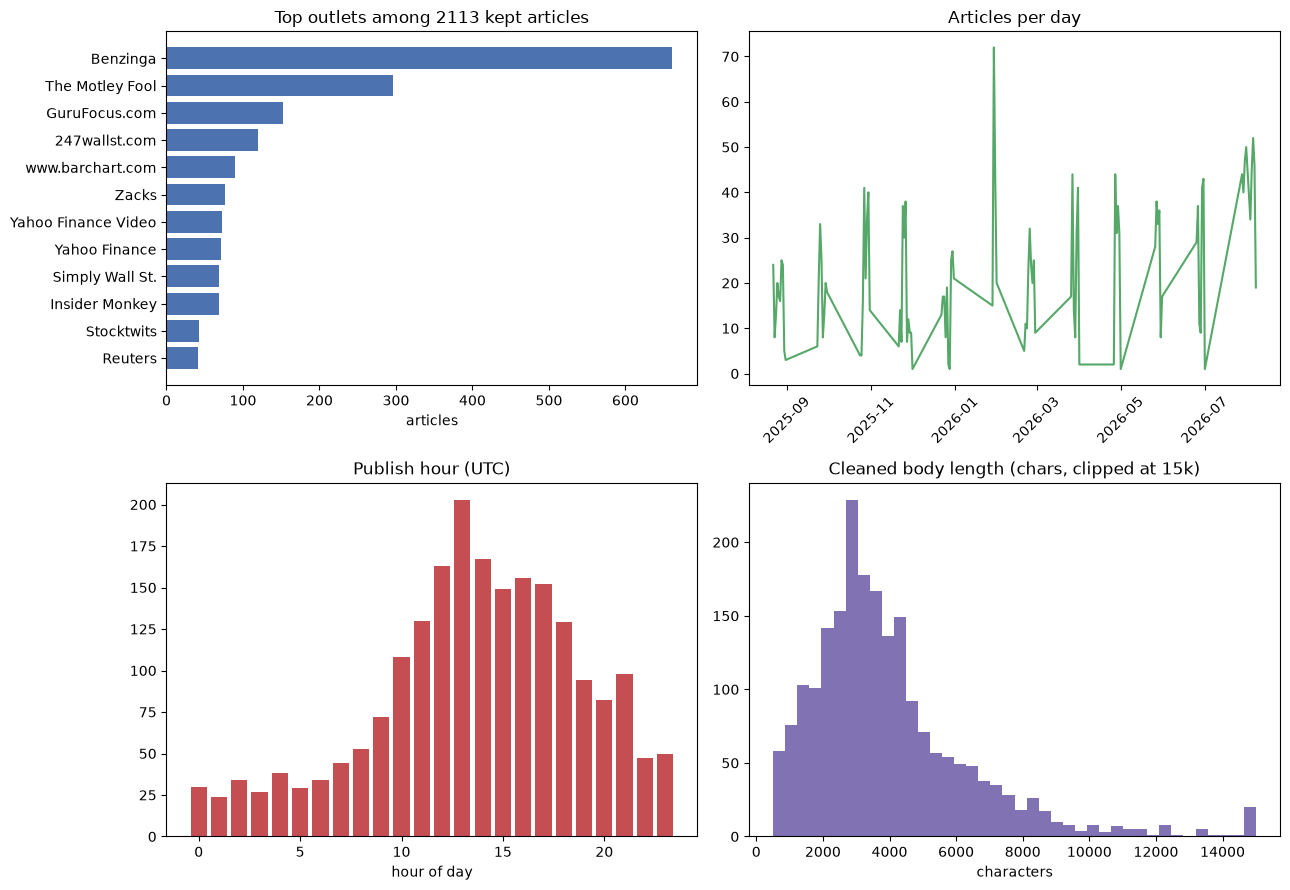

In [18]:
import matplotlib.pyplot as plt

report = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
report["hour"] = report["timestamp_utc"].dt.hour
report["day"] = report["timestamp_utc"].dt.date
report["body_len"] = report["processed_body"].str.len()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

top = report["source"].value_counts().head(12)
ax[0, 0].barh(top.index[::-1], top.values[::-1], color="#4C72B0")
ax[0, 0].set_title(f"Top outlets among {len(report)} kept articles")
ax[0, 0].set_xlabel("articles")

daily = report.groupby("day").size()
ax[0, 1].plot(list(daily.index), daily.values, color="#55A868")
ax[0, 1].set_title("Articles per day")
ax[0, 1].tick_params(axis="x", rotation=45)

hours = report["hour"].value_counts().reindex(range(24), fill_value=0)
ax[1, 0].bar(range(24), hours.values, color="#C44E52")
ax[1, 0].set_title("Publish hour (UTC)")
ax[1, 0].set_xlabel("hour of day")

ax[1, 1].hist(report["body_len"].clip(upper=15000), bins=40, color="#8172B3")
ax[1, 1].set_title("Cleaned body length (chars, clipped at 15k)")
ax[1, 1].set_xlabel("characters")

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "1.2-processed-corpus.png", dpi=120, bbox_inches="tight")
plt.show()

The kept corpus has 2,113 articles from 76 real outlets and covers about a year, from 22 August 2025 to 7 August 2026.

Benzinga is the largest with 661 articles, many of them Yahoo reposts of Benzinga, then The Motley Fool with 296, GuruFocus with 152, and 247wallst with 119, followed by a long tail of Barchart, Zacks, Simply Wall St, Insider Monkey, Reuters and dozens more. The single Yahoo label from the raw corpus is now split across all these named outlets.

Publishing follows the US trading day. It is quiet overnight, around 30 articles an hour before 07:00 UTC, then rises through the morning to a peak between 12 and 16 UTC, highest at 13 UTC with 203 articles, which is around the market open, before falling off in the evening. This is the pattern the corrected UTC time keeps accurate.

The cleaned body has a median of 3,441 characters, a minimum of 509 at the `MIN_BODY_CHARS` cutoff, and a maximum near 52k, far more than the 50-token summary we started with.

### 10. Standalone report

The notebook is the working log; the report is the finished output. This cell writes a fuller profile than the section above to `reports/1.2-processed-corpus.md`. It takes the recovery numbers from the run in memory (`merged`) and the corpus profile from the saved corpus, and it links the figure. Everything is built from the data, so the report matches whatever run produced the corpus.

In [19]:
from datetime import datetime, timezone


def _md_table(rows, header):
    """Render a list of rows as a GitHub markdown table."""
    out = "| " + " | ".join(header) + " |\n"
    out += "| " + " | ".join("---" for _ in header) + " |\n"
    for r in rows:
        out += "| " + " | ".join(str(c) for c in r) + " |\n"
    return out


# Recovery accounting, from the in-memory run.
n_open = len(merged)
reached = int(merged["status"].eq(200).sum())
accepted = int(merged["text_ok"].sum())
lost = merged[~merged["text_ok"]].copy()
lost["reason"] = "body failed"
lost.loc[lost["utc"].isna(), "reason"] = "time failed"
lost.loc[lost["status"].ne(200), "reason"] = "unreached"
reason_counts = lost["reason"].value_counts()
status_counts = lost.loc[lost["reason"].eq("unreached"), "status"].value_counts(dropna=False)
acc = merged[merged["text_ok"]]
corrected = int(acc["corrected"].sum())
per_source = merged.assign(kept=merged["text_ok"]).groupby("source").agg(
    tried=("article_id", "size"), kept=("kept", "sum"))

# Corpus profile, from the saved corpus.
p = processed_articles
t = p["timestamp_utc"]
days = t.dt.date
per_day = days.value_counts()
hours = t.dt.hour.value_counts().reindex(range(24), fill_value=0)
outlets = p["source"].value_counts()
blen = p["processed_body"].str.len()

md = []
md.append("# Processed news corpus (notebook 1.2)\n")
md.append(f"Generated {datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC from the open-corpus run, "
          f"read out of `data/processed/processed_articles.parquet`.\n")

md.append("## 1. Overview\n")
md.append(_md_table([
    ("kept articles", f"{accepted:,} of {n_open:,} open ({accepted / n_open:.1%})"),
    ("distinct outlets", f"{p['source'].nunique()}"),
    ("date span", f"{t.min():%Y-%m-%d} to {t.max():%Y-%m-%d} "
                  f"({(t.max() - t.min()).days} days, {days.nunique()} with articles)"),
], ["metric", "value"]))

md.append("\n## 2. Recovery and losses\n")
md.append("How many pages come back depends on Yahoo's rate limiting at the time of the run, so "
          "it changes from run to run. A best run has no 429 in the losses, which means nothing "
          "was throttled and only the genuinely dead pages were lost.\n\n")
md.append(_md_table([
    ("open corpus", f"{n_open:,}", "100.0%"),
    ("reached (200)", f"{reached:,}", f"{reached / n_open:.1%}"),
    ("accepted (body)", f"{accepted:,}", f"{accepted / n_open:.1%}"),
    ("lost", f"{n_open - accepted:,}", f"{(n_open - accepted) / n_open:.1%}"),
], ["stage", "count", "rate"]))
md.append("\nRejected by reason:\n\n")
md.append(_md_table([(k, f"{v:,}") for k, v in reason_counts.items()], ["reason", "count"]))
md.append("\nUnreached by status (HTTP code or error kind):\n\n")
md.append(_md_table([(k, f"{v:,}") for k, v in status_counts.items()], ["status", "count"]))
md.append(f"\nTime provenance among kept articles: {corrected:,} corrected from the page "
          f"({corrected / accepted:.1%}), {accepted - corrected:,} held at the Finnhub API floor "
          f"({1 - corrected / accepted:.1%}).\n")
md.append("\nAcceptance by raw source:\n\n")
md.append(_md_table([
    (s, f"{r.tried:,}", f"{int(r.kept):,}", f"{r.kept / r.tried:.1%}")
    for s, r in per_source.iterrows()
], ["source", "tried", "kept", "rate"]))

md.append("\n## 3. Sources\n")
md.append(f"The single Yahoo label opens into {p['source'].nunique()} real outlets. Top 20 by count:\n\n")
md.append(_md_table([(name, f"{cnt:,}") for name, cnt in outlets.head(20).items()],
                    ["outlet", "articles"]))
tail = p["source"].nunique() - min(20, p["source"].nunique())
if tail > 0:
    md.append(f"\n...and {tail} more outlets in the long tail.\n")

md.append("\n## 4. Temporal coverage\n")
md.append(_md_table([
    ("active days", f"{days.nunique()} of {(t.max() - t.min()).days} in span"),
    ("articles per active day", f"mean {per_day.mean():.1f}, median {per_day.median():.0f}"),
], ["metric", "value"]))
md.append("\nBusiest days:\n\n")
md.append(_md_table([(str(day), f"{cnt:,}") for day, cnt in per_day.sort_values(ascending=False).head(5).items()],
                    ["day", "articles"]))
md.append("\nPublish hour (UTC), all kept articles:\n\n")
md.append(_md_table([(f"{h:02d}", f"{hours[h]:,}") for h in range(24)], ["hour", "articles"]))

md.append("\n## 5. Body length (characters)\n")
md.append(_md_table([
    ("min", f"{int(blen.min()):,}"),
    ("25th pct", f"{int(blen.quantile(.25)):,}"),
    ("median", f"{int(blen.median()):,}"),
    ("mean", f"{int(blen.mean()):,}"),
    ("75th pct", f"{int(blen.quantile(.75)):,}"),
    ("max", f"{int(blen.max()):,}"),
], ["stat", "chars"]))
md.append(f"\nShare over 1,000 characters: {(blen >= 1000).mean():.1%}; over 3,000: {(blen >= 3000).mean():.1%}.\n")
md.append("\n![Processed corpus profile](figures/1.2-processed-corpus.png)\n")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
report_path = REPORTS_DIR / "1.2-processed-corpus.md"
report_path.write_text("\n".join(md), encoding="utf-8")
print(f"wrote {report_path}")

wrote C:\Users\adamw\programming-projects\Python\stock-predictor\reports\1.2-processed-corpus.md


This is the end of the text-recovery notebook. We started with a raw corpus of short summaries, a misleading source label, and unreliable times. We finish with a filtered corpus that has the real outlet, a corrected UTC time, and a full cleaned body for each article. The next notebook takes `processed_articles` into the entity filter and FinBERT sentiment scoring.